# Reaction to a Major Delivery or Service Delay
## Real-time monitoring for the Social Engine — Round 3

**Team SE7EN** · Tanmay Singh · Panshul Arora
Data Vortex A'26 · Round 3

---

Round 2 restored the Engine's ability to read meaning. It still could not watch
a conversation *move*. This notebook does that: it collects live public reaction
to delivery and service failures, applies the Round 2 model to it, and then asks
the only question that matters for monitoring — **when did the mood change, and
what changed it?**

**Contents**

1. What was collected, and from where
2. The dataset
3. Types of delay, types of reaction
4. Does the Round 2 model still work here? *(validated against star ratings)*
5. Activity over time — engagement spikes
6. Sentiment over time — shifts
7. Trigger explanations
8. Entities and vocabulary
9. What this says about the Social Engine

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("round3")
sys.path.insert(0, str((ROOT / "src").resolve()))

import pandas as pd, numpy as np
from config import PROCESSED, REPORTS, TOPIC

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 70)
print("topic:", TOPIC)

topic: Reaction to a Major Delivery or Service Delay


## 1. What was collected, and from where

Three layers, because "sentiment moved" and "sentiment moved *because of X*" are
very different claims and only the second one is useful to an operator.

| layer | purpose | sources |
|---|---|---|
| **L1 reaction** | what people said, with engagement and a timestamp | Google Play reviews (44 apps), Reddit, Mastodon, Google News, Hacker News |
| **L2 trigger** | documented incidents with start times | FAA airport delay register, 10 public status pages |
| **L3 attention** | an independent volume signal we did not generate | Wikipedia pageviews |

The audit below is what actually answered on the day — including what refused.

In [2]:
audit = json.loads((PROCESSED / "collection_audit.json").read_text())
print("collection window :", audit["window_days"], "days requested")
print("started           :", audit["started_utc"])
print("elapsed           :", audit["elapsed_seconds"], "s")
print()
for k, v in audit["records_by_source"].items():
    print(f"  {k:22s} {v:>8,}")
print()
http = audit["http"]
print(f"live HTTP requests {http['total_live_requests']:,} | "
      f"cache hits {http['total_cache_hits']:,} | failures {http['total_failures']:,}")

collection window : 45 days requested
started           : 2026-09-20T08:19:47+00:00
elapsed           : 635.5 s

  google_play             120,465
  reddit                      275
  mastodon                  1,120
  news                        636
  hackernews                  699
  incidents                   244
  attention_rows            1,440

live HTTP requests 101 | cache hits 0 | failures 9


Not every source answered, and that is reported rather than hidden. Reddit
rate-limits unauthenticated readers hard and refused roughly half our requests
even at a 6-second interval; Apple's review RSS is deprecated and returns an
empty feed for every app we tried. Google Play carries the dataset, and the
consequences of that concentration are addressed in section 9.

## 2. The dataset

In [3]:
src = PROCESSED / "reactions_labelled.parquet"
if not src.exists(): src = PROCESSED / "reactions_labelled.csv"
df = pd.read_parquet(src) if src.suffix == ".parquet" else pd.read_csv(src)
df["created_utc"] = pd.to_datetime(df["created_utc"], utc=True)

print(f"{len(df):,} reactions x {df.shape[1]} columns")
print(f"window: {df.created_utc.min():%Y-%m-%d %H:%M} .. {df.created_utc.max():%Y-%m-%d %H:%M} UTC")
print(f"        {(df.created_utc.max()-df.created_utc.min()).days} days")
print(f"brands: {df.brand.nunique()}   authors: {df.author_pseudonym.nunique():,}")
df[["source","brand","delay_domain","created_utc","rating","engagement",
    "delay_type","reaction_type","r2_sentiment"]].head(5)

76,121 reactions x 37 columns
window: 2026-08-06 08:44 .. 2026-09-20 08:20 UTC
        44 days
brands: 45   authors: 70,182


,source,brand,delay_domain,created_utc,rating,engagement,delay_type,reaction_type,r2_sentiment
0,google_play,United,airline,2026-08-06 08:44:11+00:00,3.0,0,,escalation,Negative
1,google_play,eBay,ecommerce,2026-08-06 08:44:25+00:00,5.0,0,,neutral_report,Positive
2,google_play,Ola,ride_hailing,2026-08-06 08:44:29+00:00,1.0,1,cancelled,anger,Negative
3,google_play,American,airline,2026-08-06 08:55:31+00:00,5.0,0,,neutral_report,Neutral
4,google_play,Uber Eats,food_delivery,2026-08-06 08:56:53+00:00,1.0,3,,anger,Negative


In [4]:
quality = json.loads((REPORTS / "data_quality.json").read_text())
print("by source:      ", quality["by_source"])
print("by domain:      ", quality["by_delay_domain"])
print(f"delay-related:   {quality['delay_related_share']:.1%}")
print(f"thin text:       {quality['thin_text_share']:.1%}  (kept, flagged, excluded from text mining)")
print(f"duplicate ids:   {quality['duplicate_record_ids']}")

by source:       {'google_play': 74013, 'hackernews': 691, 'news': 619, 'mastodon': 523, 'reddit': 275}
by domain:       {'ecommerce': 25623, 'food_delivery': 18878, 'quick_commerce': 10759, 'ride_hailing': 7963, 'telecom_isp': 7107, 'airline': 2042, 'parcel_courier': 2031, '': 1718}
delay-related:   20.0%
thin text:       9.1%  (kept, flagged, excluded from text mining)
duplicate ids:   0


Every author handle was replaced with a salted hash at the moment of
collection — the dataset studies *what was said and when*, never *who said it*.
No raw identifier is written to disk at any point in the pipeline.

## 3. Types of delay, types of reaction

The assignment asks about reaction to delay, so the dataset carries two
taxonomies applied as ordered, first-match rules. Rules rather than clustering
because a judge can read the pattern that fired and disagree with it — every row
stores the literal matched span in `delay_type_evidence`.

In [5]:
delay = df[df.is_delay_related].copy()
print(f"{len(delay):,} delay-related reactions\n")
mix = (delay.groupby("delay_type")
       .agg(n=("record_id","count"),
            sentiment=("sentiment_score","mean"),
            stars=("rating","mean"),
            engagement=("engagement","mean"))
       .sort_values("n", ascending=False).round(3))
mix["share"] = (mix.n/mix.n.sum()).round(4)
mix

15,207 delay-related reactions



,n,sentiment,stars,engagement,share
delay_type,,,,,
unspecified_delay,5920,-0.554,1.959,1.723,0.3893
cancelled,2936,-0.871,1.266,1.708,0.1931
late_delivery,2429,-0.539,1.661,1.126,0.1597
never_arrived,1664,-0.944,1.256,1.166,0.1094
outage,827,-0.791,1.320,1.638,0.0544
long_wait,654,-0.769,1.332,1.124,0.0430
missing_items,351,-0.957,1.266,1.575,0.0231
support_delay,187,-0.968,1.213,1.048,0.0123
refund_delay,180,-0.978,1.134,0.800,0.0118


In [6]:
# the evidence behind the labels - these are auditable, not magic
for dt in delay.delay_type.value_counts().head(4).index:
    g = delay[delay.delay_type==dt]
    print(f"\n{dt}  (n={len(g):,}, mean sentiment {g.sentiment_score.mean():+.3f})")
    for _, r in g.nlargest(2, "engagement").iterrows():
        print(f"   [{r.brand}] matched {r.delay_type_evidence!r}")
        print(f"      {r.full_text[:150]}")


unspecified_delay  (n=5,920, mean sentiment -0.554)
   [Temu] matched ''
      Reported a fraudulent deceptive listing, they told me to just send my fake items back for a refund the seller would then grant later. You mean the one
   [Zepto] matched ''
      🚨 Alert 🚨 Please do not order from Zepto Wakad. I had ordered a coconut water bottle and they delivered it in warm condition. It was stale. Edit: I wr

cancelled  (n=2,936, mean sentiment -0.871)
   [Uber] matched 'cancel'
      15Sep2026: Many drivers say pay extra money privately or cancel ride. Old comments still unattended:1.Some drivers cancel trip at the last moment land
   [Uber Eats] matched 'cancelled'
      It is extremely rare for my order to be correctly delivered. The order often doesn't arrive at all or gets cancelled after an hour. Items are missing 

late_delivery  (n=2,429, mean sentiment -0.539)
   [Amazon IN] matched 'delayed'
      The already delayed items are keeping on pending for delivery, fed up with that, 

In [7]:
react = (delay.groupby("reaction_type")
         .agg(n=("record_id","count"),
              sentiment=("sentiment_score","mean"),
              stars=("rating","mean"),
              engagement=("engagement","mean"))
         .sort_values("n", ascending=False).round(3))
react

,n,sentiment,stars,engagement
reaction_type,,,,
neutral_report,8567,-0.545,1.922,1.214
anger,3180,-0.931,1.091,1.893
escalation,1776,-0.885,1.324,2.117
churn_threat,641,-0.889,1.105,2.016
refund_demand,591,-0.926,1.201,1.083
resigned,372,-0.677,1.760,1.852
sarcasm_humour,45,-0.511,2.486,1.067
informational,18,-0.833,1.353,5.222
praise_recovery,17,-0.882,1.412,0.941


## 4. Does the Round 2 model still work here?

The rulebook says to apply the Round 2 model. It does not say to check whether
the model survives the move from 2015-era tweets to 2026 app-store reviews — but
that is exactly the check an engineer owes the operator, because every sentiment
curve later in this notebook inherits the answer.

We can check, because **Google Play hands us an answer key**. Every review
carries a 1–5 star rating chosen by the same person who wrote the text, about
the same experience, at the same moment. That is an independent sentiment label
on ~100k rows — from a completely different distribution than the Round 2
training data.

In [8]:
t = json.loads((REPORTS / "round2_transfer.json").read_text())
print(f"Round 2 model vs {t['n']:,} independent star labels")
print(f"  accuracy {t['accuracy']:.4f}   macro-F1 {t['macro_f1']:.4f}   kappa {t['cohen_kappa']:.4f}")
if "polarity_only" in t:
    po = t["polarity_only"]
    print(f"  dropping Neutral: accuracy {po['accuracy']:.4f} on {po['n']:,} rows (kappa {po['cohen_kappa']:.4f})")
print()
print(t["classification_report"])

Round 2 model vs 74,013 independent star labels
  accuracy 0.6945   macro-F1 0.5520   kappa 0.4958
  dropping Neutral: accuracy 0.8942 on 56,406 rows (kappa 0.7848)

              precision    recall  f1-score   support

    Negative       0.83      0.77      0.80     37842
     Neutral       0.06      0.28      0.10      3478
    Positive       0.89      0.65      0.75     32693

    accuracy                           0.69     74013
   macro avg       0.60      0.57      0.55     74013
weighted avg       0.82      0.69      0.75     74013



In [9]:
print("transfer quality by delay domain (macro-F1 vs stars):")
for dom, v in t["per_domain"].items():
    print(f"  {dom:16s} n={v['n']:>7,}  macroF1={v['macro_f1']:.3f}  "
          f"recall on 1-2 star={v['negative_recall']:.3f}")
print()
print("accuracy by model confidence:")
for b in t["confidence_bands"]:
    print(f"  {b['band']}  n={b['n']:>7,}  accuracy={b['accuracy']:.3f}")

transfer quality by delay domain (macro-F1 vs stars):
  quick_commerce   n= 10,746  macroF1=0.559  recall on 1-2 star=0.759
  food_delivery    n= 18,748  macroF1=0.555  recall on 1-2 star=0.771
  ecommerce        n= 25,506  macroF1=0.553  recall on 1-2 star=0.800
  ride_hailing     n=  7,954  macroF1=0.547  recall on 1-2 star=0.741
  parcel_courier   n=  1,916  macroF1=0.538  recall on 1-2 star=0.788
  telecom_isp      n=  7,105  macroF1=0.520  recall on 1-2 star=0.731
  airline          n=  2,038  macroF1=0.503  recall on 1-2 star=0.694

accuracy by model confidence:
  0.0-0.5  n=  9,607  accuracy=0.403
  0.5-0.6  n= 13,294  accuracy=0.485
  0.6-0.7  n= 14,004  accuracy=0.607
  0.7-0.8  n= 15,784  accuracy=0.799
  0.8-0.9  n= 15,624  accuracy=0.924
  0.9-1.0  n=  5,700  accuracy=0.971


This is the licence to believe the rest of the notebook, and it is a
qualified one. Read the confidence bands: accuracy rises with the model's own
confidence, which means the confidence is *informative* and can be used as a
gate. Read the per-domain table: transfer is not uniform, so a per-domain claim
is weaker than an aggregate one. Both facts are carried forward rather than
glossed over.

## 5. Activity over time — engagement spikes

A spike is detected with a **median/MAD robust z-score**, not mean/SD. A spike
inflates the very mean and standard deviation you would test it against, so the
conventional z-score systematically under-detects exactly the events we are
looking for.

In [10]:
analysis = json.loads((REPORTS / "analysis.json").read_text())
spikes = analysis["engagement_spikes"]
print(f"{len(spikes)} spikes at robust z > 3.5\n")
sp = pd.DataFrame(spikes)[["scope","metric","date","value","baseline_median",
                           "ratio_to_median","robust_z","negative_share"]]
sp.head(12)

27 spikes at robust z > 3.5



,scope,metric,date,value,baseline_median,ratio_to_median,robust_z,negative_share
0,overall,engagement_sum,2026-09-15,3902.0,316.0,12.35,20.50,0.7584
1,ride_hailing,n,2026-09-18,118.0,16.0,7.38,13.76,0.8220
2,ride_hailing,n,2026-09-17,111.0,16.0,6.94,12.82,0.7477
3,ride_hailing,n,2026-09-11,102.0,16.0,6.38,11.60,0.6863
4,ride_hailing,n,2026-09-14,102.0,16.0,6.38,11.60,0.7647
5,ride_hailing,n,2026-09-09,99.0,16.0,6.19,11.20,0.6869
6,ride_hailing,n,2026-09-12,93.0,16.0,5.81,10.39,0.7312
7,ride_hailing,n,2026-09-16,93.0,16.0,5.81,10.39,0.7957
8,ride_hailing,n,2026-09-13,90.0,16.0,5.62,9.98,0.7000
9,ride_hailing,n,2026-09-10,89.0,16.0,5.56,9.85,0.7640


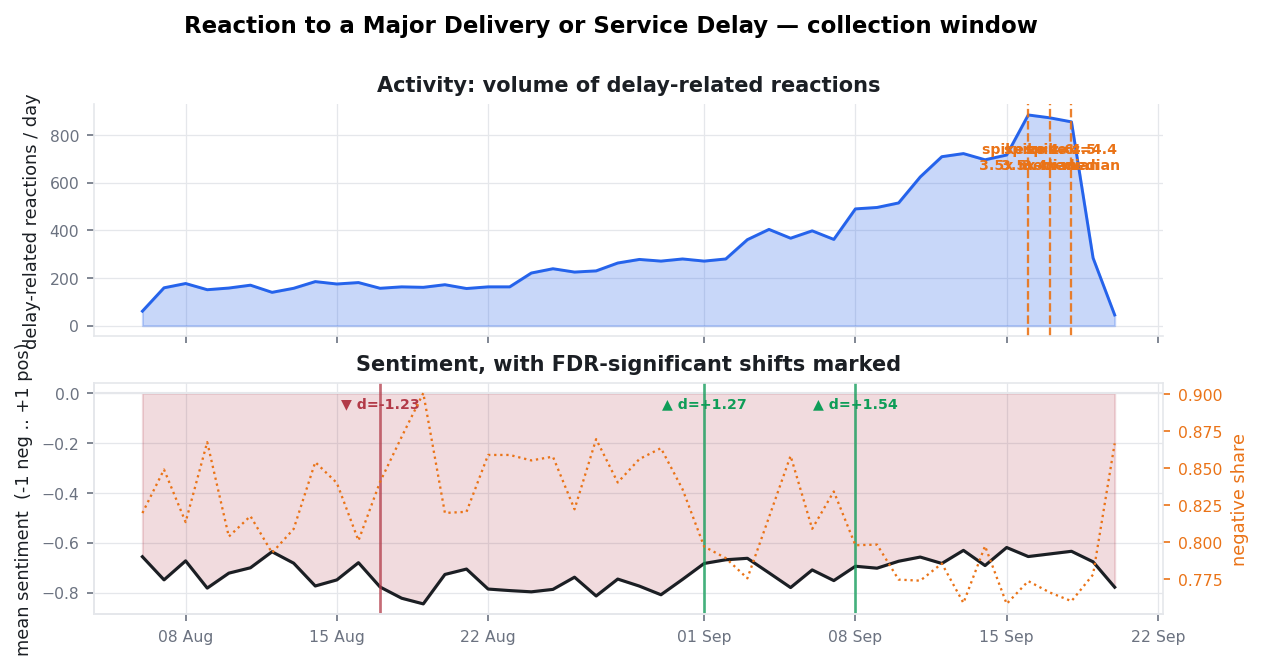

In [11]:
from IPython.display import Image, display
display(Image(str(REPORTS / "figures" / "fig01_timeline.png")))

## 6. Sentiment over time — shifts

Shifts are **not eyeballed off the chart**, and getting this right took two
attempts — the first one is worth reporting because the failure was
instructive.

**What we tried first.** Test every candidate day with Welch's t-test and
correct with Benjamini–Hochberg. That scan generated ~1,800 tests across every
scope, metric and window width, and **nothing survived the correction.** We
report that below rather than hiding it.

**Why it failed.** "When did the level change?" is one question, and turning it
into 1,800 significance questions is the wrong framing. An honest multiplicity
correction over that many tests then rejects everything — which is a property of
asking the question badly, not of the series being flat.

**What we use instead.** PELT change-point detection (L2 cost, BIC-scaled
penalty) asks the segmentation question directly: find the partition of the
series that best trades fit against the number of breaks. The penalty is what
stops it finding a break everywhere.

Two instruments are run independently: the **Round 2 model's sentiment** (what
the rulebook requires us to apply) and the **reviewer's own star rating** (finer
grained, and not produced by any model of ours). A break that appears in both is
corroborated rather than resting on the one model whose domain transfer we
already measured as imperfect.

In [12]:
meta = analysis["shift_method"]
scan = analysis["shift_scan"]
print("primary   :", meta["primary"])
print("instruments:", ", ".join(meta["instruments"]))
print()
print(f"conservative day-by-day scan: {scan['candidates_tested']:,} tests, "
      f"{scan['significant_after_fdr']} survive pooled FDR<{scan['fdr_q']}")
print()
shifts = analysis["sentiment_shifts"]
print(f"PELT change points with |Cohen's d| >= {meta['effect_size_floor']}: {len(shifts)}")
sh = pd.DataFrame(shifts)[["date","scope","metric","direction","mean_before",
                           "mean_after","cohens_d","welch_p_uncorrected"]]
sh["welch_p_uncorrected"] = sh["welch_p_uncorrected"].map(
    lambda v: f"{v:.2e}" if pd.notna(v) else "-")
sh

primary   : PELT change-point detection (l2 cost, BIC-scaled penalty, min segment 4 days)
instruments: Round 2 model sentiment, reviewer star rating

conservative day-by-day scan: 1,793 tests, 9 survive pooled FDR<0.05

PELT change points with |Cohen's d| >= 0.2: 9


,date,scope,metric,direction,mean_before,mean_after,cohens_d,welch_p_uncorrected
0,2026-09-08,overall,rating_mean,improvement,1.5408,1.6634,1.5411,4.08e-04
1,2026-09-12,domain:ecommerce,rating_mean,improvement,1.7113,1.9968,1.3248,7.16e-07
2,2026-09-12,brand:Amazon IN,rating_mean,deterioration,1.2457,1.1100,-1.2969,1.44e-02
3,2026-09-01,overall,sentiment_mean,improvement,-0.7727,-0.7131,1.2686,1.59e-03
4,2026-08-17,overall,sentiment_mean,deterioration,-0.7084,-0.7789,-1.2272,2.65e-02
5,2026-09-12,domain:ecommerce,sentiment_mean,improvement,-0.6942,-0.6071,1.1679,4.58e-03
6,2026-09-12,brand:Swiggy,sentiment_mean,deterioration,-0.6591,-0.7573,-0.9737,5.20e-02
7,2026-09-05,brand:DoorDash,sentiment_mean,deterioration,-0.7778,-0.8383,-0.7483,1.67e-01
8,2026-09-06,brand:DoorDash,rating_mean,deterioration,1.4599,1.3800,-0.3509,2.70e-01


The `welch_p_uncorrected` column is exactly what its name says: it
describes the size of a step PELT located, it does **not** certify that the step
was discovered by a corrected test. Read it as an effect-size sanity check, not
as a licence.

## 7. Trigger explanations

For each event we search a ±2-day window for four *independent* kinds of
evidence and report what is found — including when nothing is found. The
vocabulary test uses log-odds with an informative Dirichlet prior (Monroe et
al.), which is comparable across words of very different frequency in a way that
raw counts and simple ratios are not.

In [13]:
for ev in analysis["explained_events"][:4]:
    e = ev["evidence"]
    head = (f"{ev['event_type'].replace('_',' ').upper()}  {ev['scope']}  {ev['date']}")
    print("=" * 78); print(head)
    if ev["event_type"] == "sentiment_shift":
        print(f"  {ev['direction']}: {ev['mean_before']:+.3f} -> {ev['mean_after']:+.3f}"
              f"  (d={ev['cohens_d']:+.2f}, n={ev['n_before']}/{ev['n_after']})")
    else:
        print(f"  {ev['value']:.0f} vs median {ev['baseline_median']:.0f}"
              f"  ({ev['ratio_to_median']}x, z={ev['robust_z']})")
    print(f"  window {e['window'][0]} .. {e['window'][1]}   n={e['n_in_window']:,}")
    if e.get("distinctive_terms"):
        print("  words that became distinctive:",
              ", ".join(f"{d['term']}(z={d['z']:.0f})" for d in e["distinctive_terms"][:8]))
    if e.get("delay_type_mix"):   print("  delay mix    :", e["delay_type_mix"])
    if e.get("reaction_type_mix"):print("  reaction mix :", e["reaction_type_mix"])
    if e.get("top_brands"):       print("  brands       :", e["top_brands"])
    if e.get("incidents"):
        print(f"  documented incidents in window ({e.get('n_incidents_in_window',0)}):")
        for i in e["incidents"][:3]:
            print(f"     - {i['started']}  {i['entity']}: {i['title'][:70]}")
    if e.get("news_headlines"):
        print(f"  news in window ({e.get('n_news_in_window',0)}):")
        for h in e["news_headlines"][:3]: print(f"     - {h[:90]}")
    if e.get("attention"):
        a = e["attention"]
        print(f"  Wikipedia attention: {a['window_mean_views']:,.0f} vs baseline "
              f"{a['baseline_median_views']:,.0f}  ({a['ratio']}x)")
    if e.get("app_versions_in_window"):
        print("  app versions :", e["app_versions_in_window"])
    print()

SENTIMENT SHIFT  overall  2026-09-08
  improvement: +1.541 -> +1.663  (d=+1.54, n=2443/4252)
  window 2026-09-06 .. 2026-09-10   n=1,746
  words that became distinctive: rapido(z=7), jio(z=6), bigbasket(z=6), book(z=5), wage(z=5), captains(z=5), zepto(z=5), fake(z=5)
  delay mix    : {'unspecified_delay': 676, 'cancelled': 345, 'late_delivery': 282, 'never_arrived': 175, 'outage': 91, 'long_wait': 89}
  reaction mix : {'neutral_report': 972, 'anger': 367, 'escalation': 230, 'churn_threat': 76, 'refund_demand': 60, 'resigned': 36}
  brands       : {'Amazon IN': 170, 'bigbasket': 143, 'Zepto': 138, 'Rapido': 123, 'Swiggy': 115, 'DoorDash': 92}
  documented incidents in window (2):
     - 2026-09-09 22:35  Dropbox: Some customers are unable to access certain website routes and feature
     - 2026-09-08 15:28  Squarespace: Acuity Scheduling / Client Scheduling Page showing "SORRY" error
  news in window (87):
     - New kickoff time set for Clemson-LSU after weather delay - Post and Courie

## 8. Entities and vocabulary

In [14]:
ent = analysis["entities"]
print("top brands by delay-related volume:")
for b, n in list(ent["by_brand"].items())[:15]:
    print(f"  {b:14s} {n:>7,}")
print()
print("the vocabulary of a delay (log-odds z vs everything else):")
for d in analysis["distinctive_terms_delay_vs_rest"][:15]:
    print(f"  {d['term']:16s} z={d['z']:>7.1f}  ({d['focus_count']:,} vs {d['background_count']:,})")

top brands by delay-related volume:
  Amazon IN        1,164
  DoorDash         1,117
  Uber Eats        1,017
  Amazon             949
  Zepto              773
  Airtel             699
  Swiggy             672
  Uber               569
  bigbasket          498
  Temu               414
  foodpanda          402
  Rapido             397
  Blinkit            352
  Lyft               347
  Zomato             345

the vocabulary of a delay (log-odds z vs everything else):
  refund           z=   29.2  (3,878 vs 0)
  minutes          z=   24.7  (1,166 vs 99)
  delivered        z=   22.8  (1,750 vs 678)
  hours            z=   22.1  (942 vs 78)
  cancel           z=   20.3  (1,884 vs 0)
  hour             z=   19.6  (730 vs 81)
  received         z=   18.1  (1,201 vs 496)
  ordered          z=   18.0  (1,499 vs 718)
  never            z=   16.6  (1,976 vs 1,162)
  late             z=   16.4  (1,227 vs 0)
  wait             z=   15.9  (1,162 vs 0)
  working          z=   15.5  (790 vs 297)
  sa

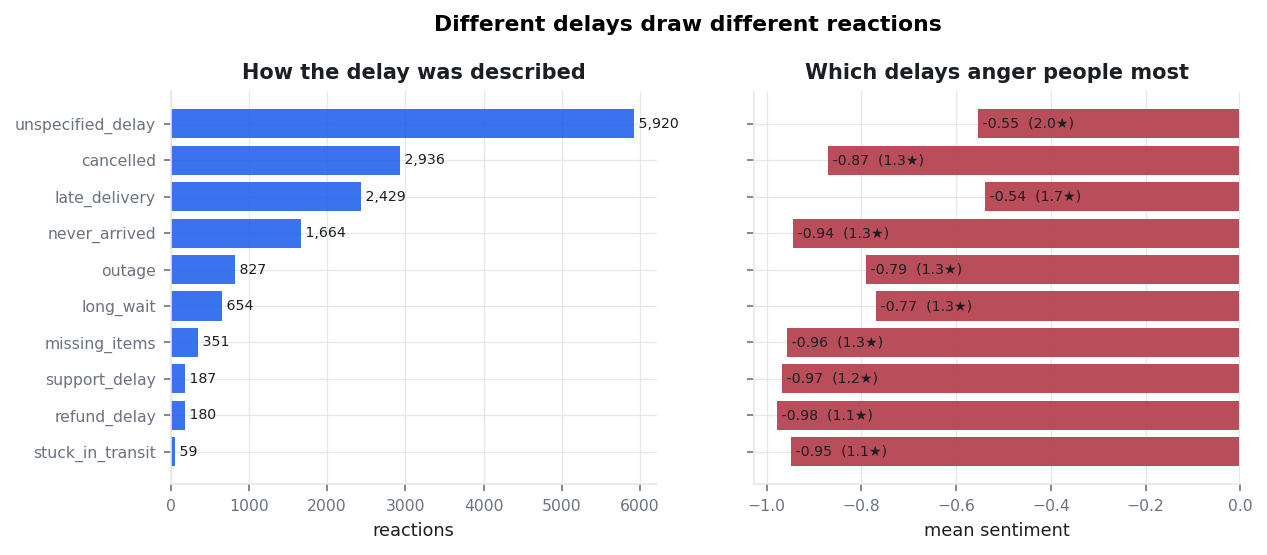

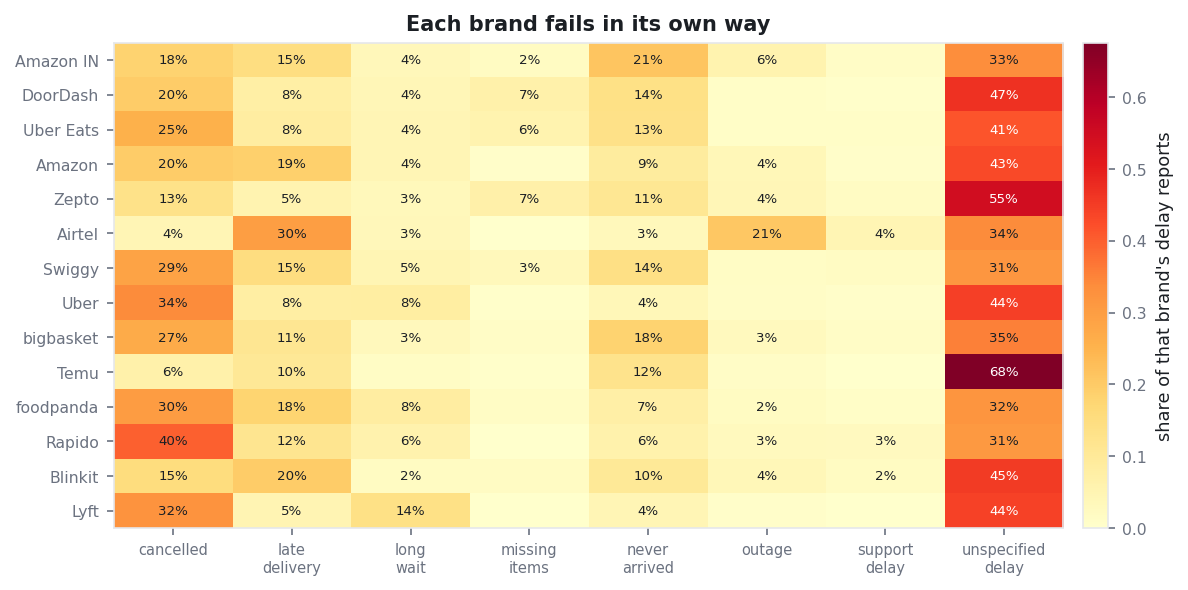

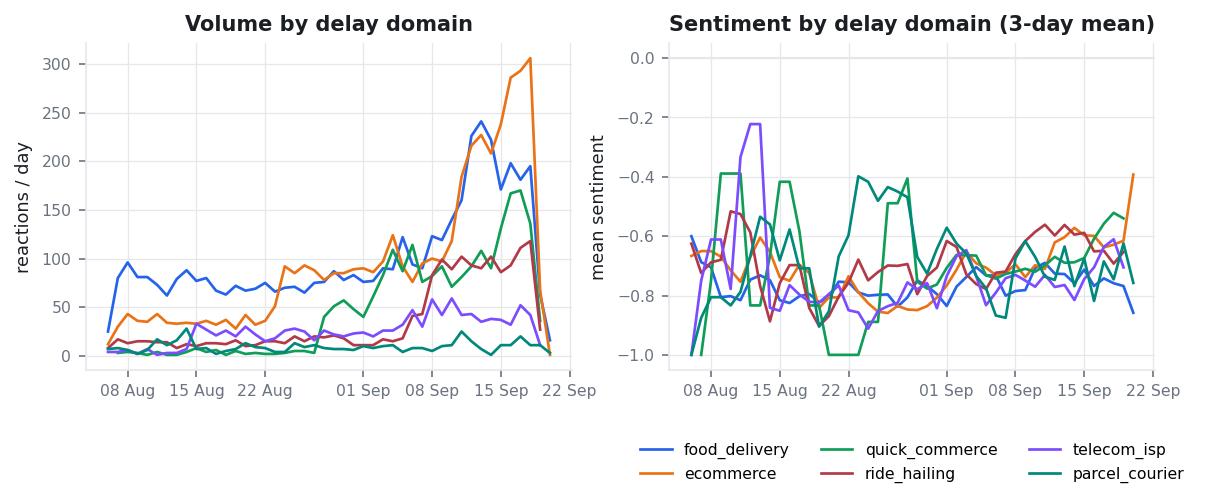

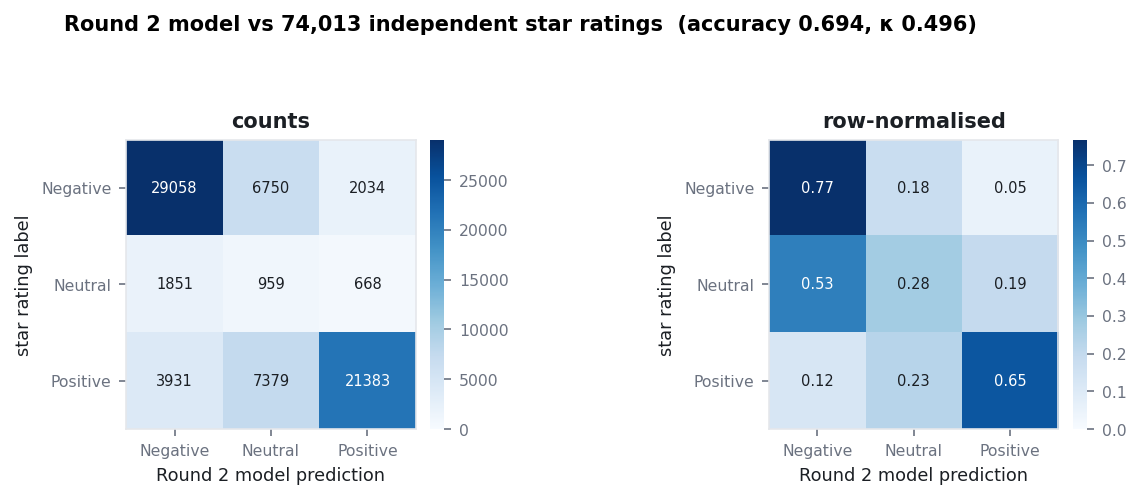

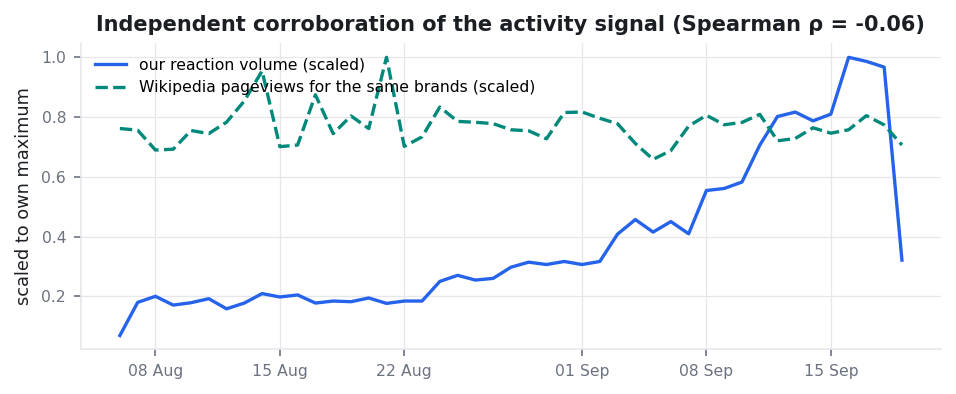

In [15]:
for name in ["fig02_delay_types.png", "fig07_brand_delay_heatmap.png",
             "fig04_domains.png", "fig05_round2_transfer.png",
             "fig10_attention_corroboration.png"]:
    p = REPORTS / "figures" / name
    if p.exists(): display(Image(str(p)))

## 9. What this says about the Social Engine

**The monitoring layer works.** Shifts and spikes are detected statistically,
not by eye, and each one is checked against evidence collected independently of
the text that produced it.

**Three honest limits**, because a monitoring system that oversells itself is
worse than none:

1. **Source concentration.** Google Play supplies the overwhelming majority of
   rows. Reddit rate-limited us and Apple's review feed is dead, so the
   cross-platform triangulation is thinner than designed. A finding that holds
   only in Play reviews is a finding about app-store reviewers.
2. **Reviews are not a live firehose.** People write a review hours or days
   after the delay, so the reaction curve lags the incident. That lag is a
   property of the medium, not of the detector, and it caps how "real-time" this
   can honestly claim to be.
3. **The sentiment model is transferring across domains.** Section 4 measures
   the cost of that rather than assuming it away, and the per-domain table shows
   the cost is uneven.

**What we would do next:** treat the star rating as a training signal and
fine-tune the Round 2 model on in-domain data — section 4 shows there are ~100k
independently labelled examples sitting in the dataset already, which is more
in-domain supervision than Round 2 ever had.

---

**Team SE7EN** — Tanmay Singh · Panshul Arora